# Getting Started with harv

**harv** is a JAX-based package for inferring orbital parameters of binary systems from time-series observations. It uses rejection sampling with analytical marginalization over linear parameters to efficiently explore the posterior distribution.

This tutorial will walk you through:
1. Simulating observations (astrometry and radial velocity)
2. Setting up priors for orbital parameters
3. Running rejection sampling
4. Analyzing and visualizing the results

## Installation

```bash
pip install harv
```

Or for development:
```bash
git clone https://github.com/adrn/harv.git
cd harv
pip install -e .
```

In [ ]:
import jax
import matplotlib.pyplot as plt
import numpy as np
from unxt import Quantity, ustrip

jax.config.update("jax_enable_x64", True)

# harv imports
from harv.data import GaiaAstrometryData, RadialVelocityData, SourceData
from harv.priors import RejectionPrior
from harv.samplers import RejectionSampler
from harv.simulate import simulate_gaia_epoch_astrometry, simulate_rv_sb1_data

## Part 1: Simulating Gaia Astrometry

Let's start by simulating Gaia-like epoch astrometry for a binary system. The simulation generates along-scan (AL) position measurements at realistic observation times with realistic scan angles.

In [2]:
# Simulate Gaia astrometry for a binary with known parameters
astro_data, true_params = simulate_gaia_epoch_astrometry(
    seed=42,
    n_obs=50,  # Number of observations (typical for Gaia DR3, a bit on the low end)
    # Orbital parameters
    period=Quantity(365.25, "day"),  # 1 year period
    eccentricity=0.3,  # Moderate eccentricity
    inclination=Quantity(60, "deg"),  # Inclination from face-on
    arg_peri=Quantity(45, "deg"),  # Argument of pericenter
    lon_asc_node=Quantity(120, "deg"),  # Longitude of ascending node
    # Physical parameters
    semimajor_axis=Quantity(2.5, "mas"),  # Angular semimajor axis
    parallax=Quantity(10, "mas"),  # Distance = 100 pc
    # Proper motion
    mu_alpha=Quantity(5, "mas/yr"),  # Proper motion in RA
    mu_delta=Quantity(-3, "mas/yr"),  # Proper motion in Dec
    # Measurement noise
    al_error=Quantity(0.4, "mas"),  # Along-scan error per observation
)

print(f"Number of observations: {len(astro_data.time)}")
print(f"\nTrue orbital parameters:")
for key, val in true_params.items():
    print(f"  {key}: {val}")

Number of observations: 50

True orbital parameters:
  period: Quantity['time'](365.25, unit='d')
  eccentricity: 0.3
  semimajor_axis: Quantity['angle'](2.5, unit='mas')
  t_peri: Quantity['time'](279.02647991, unit='d')
  alpha0: Quantity['angle'](0., unit='mas')
  delta0: Quantity['angle'](0., unit='mas')
  mu_alpha: Quantity['angular frequency'](5, unit='mas / yr')
  mu_delta: Quantity['angular frequency'](-3, unit='mas / yr')
  parallax: Quantity['angle'](10, unit='mas')
  A: Quantity['angle'](-1.64934902, unit='mas')
  B: Quantity['angle'](1.08898935, unit='mas')
  F: Quantity['angle'](0.11841793, unit='mas')
  G: Quantity['angle'](-1.97287283, unit='mas')
  arg_peri: Quantity['angle'](45, unit='deg')
  lon_asc_node: Quantity['angle'](120, unit='deg')
  inclination: Quantity['angle'](60, unit='deg')


/var/folders/67/2zgxpmyd2z183j4k6r33nf740000gr/T/ipykernel_64407/1924549340.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


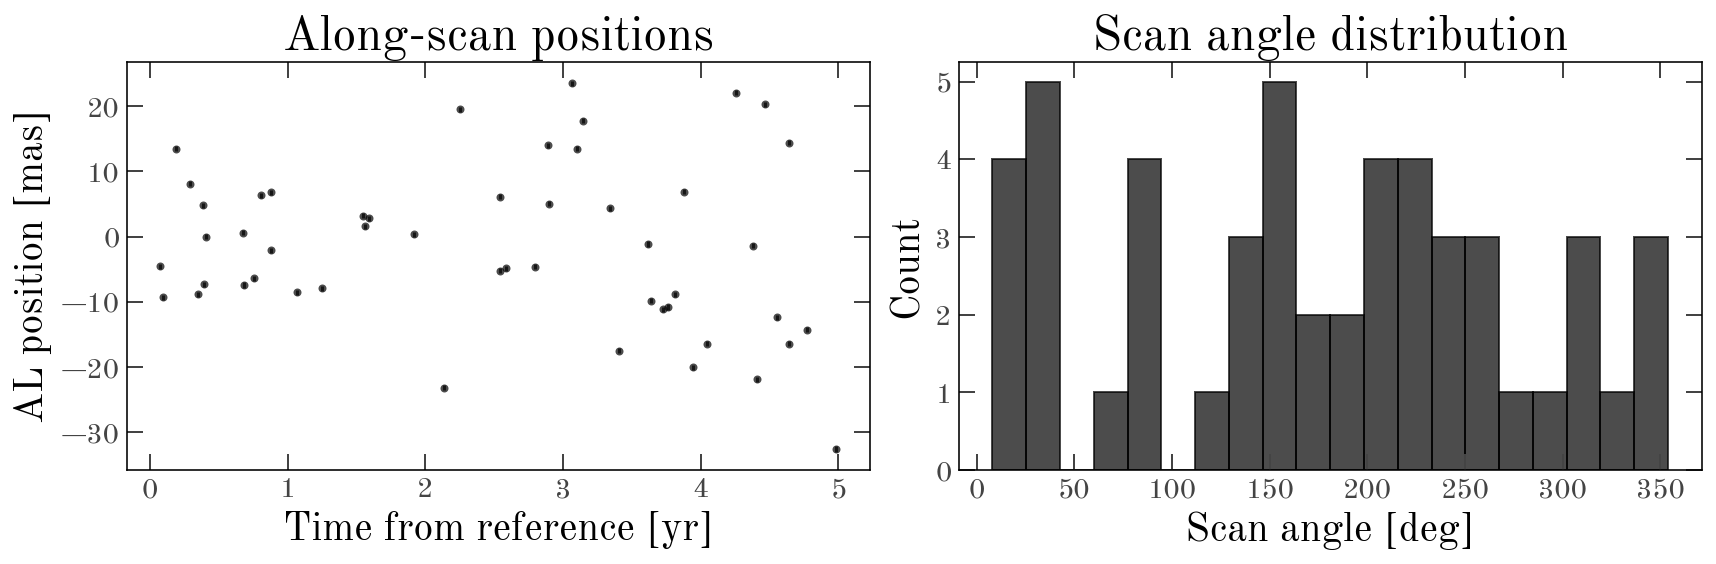

In [3]:
# Visualize the simulated data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot AL positions vs time
ax = axes[0]
times_yr = (astro_data.time - astro_data.t_ref).to_value("yr")
ax.errorbar(
    times_yr,
    astro_data.al_position.to_value("mas"),
    yerr=astro_data.al_position_err.to_value("mas"),
    fmt="o",
    ms=4,
    alpha=0.7,
)
ax.set_xlabel("Time from reference [yr]")
ax.set_ylabel("AL position [mas]")
ax.set_title("Along-scan positions")

# Plot scan angle distribution
ax = axes[1]
ax.hist(astro_data.scan_angle.to_value("deg"), bins=20, edgecolor="k", alpha=0.7)
ax.set_xlabel("Scan angle [deg]")
ax.set_ylabel("Count")
ax.set_title("Scan angle distribution")

plt.tight_layout()
plt.show()

## Part 2: Setting Up the Prior

harv uses rejection sampling, which requires specifying prior distributions for the orbital parameters. The package provides convenient factory methods for common use cases.

### Parameter Types

The parameters are split into two groups:

**Nonlinear parameters** (sampled from the prior):
- `log_period`: log₁₀(period/day)
- `eccentricity`: orbital eccentricity [0, 1)
- `phase_peri`: phase at pericenter (t_peri / period) [0, 1)
- `cos_i`: cosine of inclination [-1, 1] (for astrometry)
- `arg_peri`: argument of pericenter [0, 2π]
- `lon_asc_node`: longitude of ascending node [0, 2π] (for astrometry)

**Linear parameters** (analytically marginalized):
- For astrometry: α₀, δ₀, μ_α, μ_δ, parallax, semimajor_axis
- For RV: K (semi-amplitude), v₀ (systemic velocity)

In [4]:
# Create a default prior for astrometry
prior = RejectionPrior.default_astrometry(
    log_period_min=1.0,  # 10 days minimum
    log_period_max=4.0,  # 10,000 days maximum (~27 years)
    linear_prior_scale=1000.0,  # Scale for linear parameter prior (mas)
)

print(f"Number of nonlinear parameters: {prior.n_nonlinear}")
print(f"\nNonlinear parameters with priors:")
print(f"  log_period: {prior.log_period}")
print(f"  eccentricity: {prior.eccentricity}")
print(f"  phase_peri: {prior.phase_peri}")
print(f"  cos_i: {prior.cos_i}")
print(f"  arg_peri: {prior.arg_peri}")
print(f"  lon_asc_node: {prior.lon_asc_node}")

Number of nonlinear parameters: 6

Nonlinear parameters with priors:
  log_period: <numpyro.distributions.continuous.Uniform object at 0x139837c80 with batch shape () and event shape ()>
  eccentricity: <numpyro.distributions.continuous.Beta object at 0x139837830 with batch shape () and event shape ()>
  phase_peri: <numpyro.distributions.continuous.Uniform object at 0x139836150 with batch shape () and event shape ()>
  cos_i: <numpyro.distributions.continuous.Uniform object at 0x1398f9190 with batch shape () and event shape ()>
  arg_peri: <numpyro.distributions.continuous.Uniform object at 0x139da9d90 with batch shape () and event shape ()>
  lon_asc_node: <numpyro.distributions.continuous.Uniform object at 0x139da9010 with batch shape () and event shape ()>


### Eccentricity Prior

By default, the eccentricity prior uses the Beta(0.867, 3.03) distribution from [Kipping (2013)](https://arxiv.org/abs/1306.4982), which is derived from the observed eccentricity distribution of exoplanets.

W0313 16:44:53.348039 19633301 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


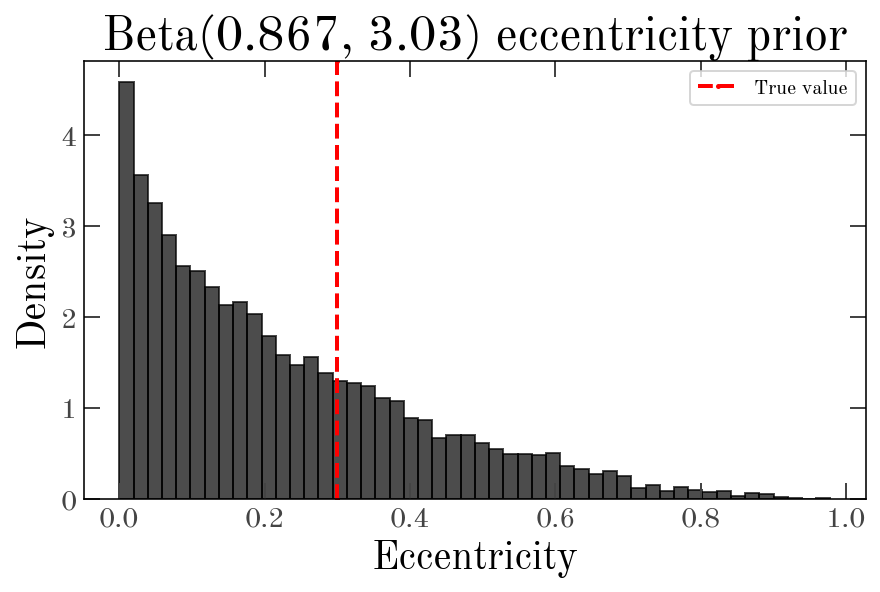

In [5]:
# Visualize the eccentricity prior
import jax.random as jr

ecc_samples = prior.eccentricity.sample(jr.PRNGKey(0), (10000,))

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.asarray(ecc_samples), bins=50, density=True, alpha=0.7, edgecolor="k")
ax.axvline(true_params["eccentricity"], color="r", ls="--", lw=2, label="True value")
ax.set_xlabel("Eccentricity")
ax.set_ylabel("Density")
ax.set_title("Beta(0.867, 3.03) eccentricity prior")
ax.legend()
plt.show()

## Part 3: Running Rejection Sampling

Now we can run the rejection sampler. The algorithm:
1. Draws samples from the prior over nonlinear parameters
2. For each sample, computes the marginalized likelihood (analytically integrating over linear parameters)
3. Performs rejection sampling based on the likelihood values
4. For accepted samples, draws linear parameters from their conditional posterior

This approach is very efficient because:
- Linear parameters are handled analytically (no MCMC needed for them)
- The computation is fully vectorized with JAX
- It can handle very large prior sample sizes

In [6]:
# Create the sampler
sampler = RejectionSampler(prior)

# Run rejection sampling
# Note: The first run may be slow due to JIT compilation
n_prior_samples = 4_000_000
samples = sampler.run(
    astro_data,
    n_prior_samples=n_prior_samples,  # Number of prior samples to evaluate
    seed=42,
)

print(f"Number of accepted samples: {samples.n_samples}")
print(f"Acceptance rate: {samples.n_samples / n_prior_samples:.2%}")

Number of accepted samples: 2
Acceptance rate: 0.00%


/Users/aprice-whelan/projects/harv/src/harv/samplers/rejection.py:251: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Samples(


In [7]:
samples.summary()

{'arg_peri': {'median': Quantity(Array(2.73122653, dtype=float64), unit='rad'),
  'mean': Quantity(Array(2.73122653, dtype=float64), unit='rad'),
  'std': Quantity(Array(1.21319081, dtype=float64), unit='rad'),
  'p16': Quantity(Array(1.90625677, dtype=float64), unit='rad'),
  'p84': Quantity(Array(3.55619628, dtype=float64), unit='rad')},
 'cos_i': {'median': 0.761954091913895,
  'mean': 0.761954091913895,
  'std': 0.12422778469364237,
  'p16': 0.677479198322218,
  'p84': 0.8464289855055718},
 'eccentricity': {'median': 0.28259012049885446,
  'mean': 0.28259012049885446,
  'std': 0.02504244551847032,
  'p16': 0.26556125754629467,
  'p84': 0.2996189834514143},
 'log_period': {'median': 2.5598245078607897,
  'mean': 2.5598245078607897,
  'std': 0.0007595824528727757,
  'p16': 2.559307991792836,
  'p84': 2.560341023928743},
 'lon_asc_node': {'median': Quantity(Array(3.22272685, dtype=float64), unit='rad'),
  'mean': Quantity(Array(3.22272685, dtype=float64), unit='rad'),
  'std': Quantit

## Part 4: Analyzing the Results

The `Samples` object provides convenient access to posterior samples with automatic unit handling.

In [8]:
# Access samples - units are automatically restored
print("Available parameters:")
print(samples.keys())

print("\nPeriod samples (first 5):")
print(samples["period"][:5])

print("\nParallax samples (first 5):")
print(samples["parallax"][:5])

Available parameters:
['arg_peri', 'cos_i', 'eccentricity', 'log_period', 'lon_asc_node', 'phase_peri', 'alpha_0', 'delta_0', 'mu_alpha', 'mu_delta', 'parallax', 'semimajor_axis', 'period', 't_peri', 'inclination']

Period samples (first 5):
Quantity['time']([363.56669337, 362.29715644], unit='d')

Parallax samples (first 5):
Quantity['angle']([10.71393669, 10.35824634], unit='mas')


In [9]:
# Get summary statistics
summary = samples.summary(["period", "eccentricity", "parallax", "semimajor_axis"])

print("Parameter summary:")
print("-" * 60)
for param, stats in summary.items():
    print(f"\n{param}:")
    for stat_name, value in stats.items():
        print(f"  {stat_name}: {value}")

Parameter summary:
------------------------------------------------------------

period:
  median: Quantity['time'](362.93192491, unit='d')
  mean: Quantity['time'](362.93192491, unit='d')
  std: Quantity['time'](0.63476846, unit='d')
  p16: Quantity['time'](362.50028235, unit='d')
  p84: Quantity['time'](363.36356746, unit='d')

eccentricity:
  median: 0.28259012049885446
  mean: 0.28259012049885446
  std: 0.02504244551847032
  p16: 0.26556125754629467
  p84: 0.2996189834514143

parallax:
  median: Quantity['angle'](10.53609152, unit='mas')
  mean: Quantity['angle'](10.53609152, unit='mas')
  std: Quantity['angle'](0.17784518, unit='mas')
  p16: Quantity['angle'](10.41515679, unit='mas')
  p84: Quantity['angle'](10.65702624, unit='mas')

semimajor_axis:
  median: Quantity['angle'](-2.13212611, unit='mas')
  mean: Quantity['angle'](-2.13212611, unit='mas')
  std: Quantity['angle'](0.02773876, unit='mas')
  p16: Quantity['angle'](-2.15098846, unit='mas')
  p84: Quantity['angle'](-2.1132

In [10]:
# Compare with true values
print("Comparison with true values:")
print("-" * 60)

# Period
period_median = samples.median("period")
print(f"Period: {period_median} (true: {true_params['period']})")

# Eccentricity
ecc_median = samples.median("eccentricity")
print(f"Eccentricity: {float(ecc_median)} (true: {true_params['eccentricity']})")

# Parallax
plx_median = samples.median("parallax")
print(f"Parallax: {plx_median} (true: {true_params['parallax']})")

# Semimajor axis
a_median = samples.median("semimajor_axis")
print(f"Semimajor axis: {a_median} (true: {true_params['semimajor_axis']})")

Comparison with true values:
------------------------------------------------------------
Period: Quantity['time'](362.93192491, unit='d') (true: Quantity['time'](365.25, unit='d'))
Eccentricity: 0.28259012049885446 (true: 0.3)
Parallax: Quantity['angle'](10.53609152, unit='mas') (true: Quantity['angle'](10, unit='mas'))
Semimajor axis: Quantity['angle'](-2.13212611, unit='mas') (true: Quantity['angle'](2.5, unit='mas'))


## Part 5: Visualization

The `Samples` class provides built-in plotting capabilities using the `arviz` library.

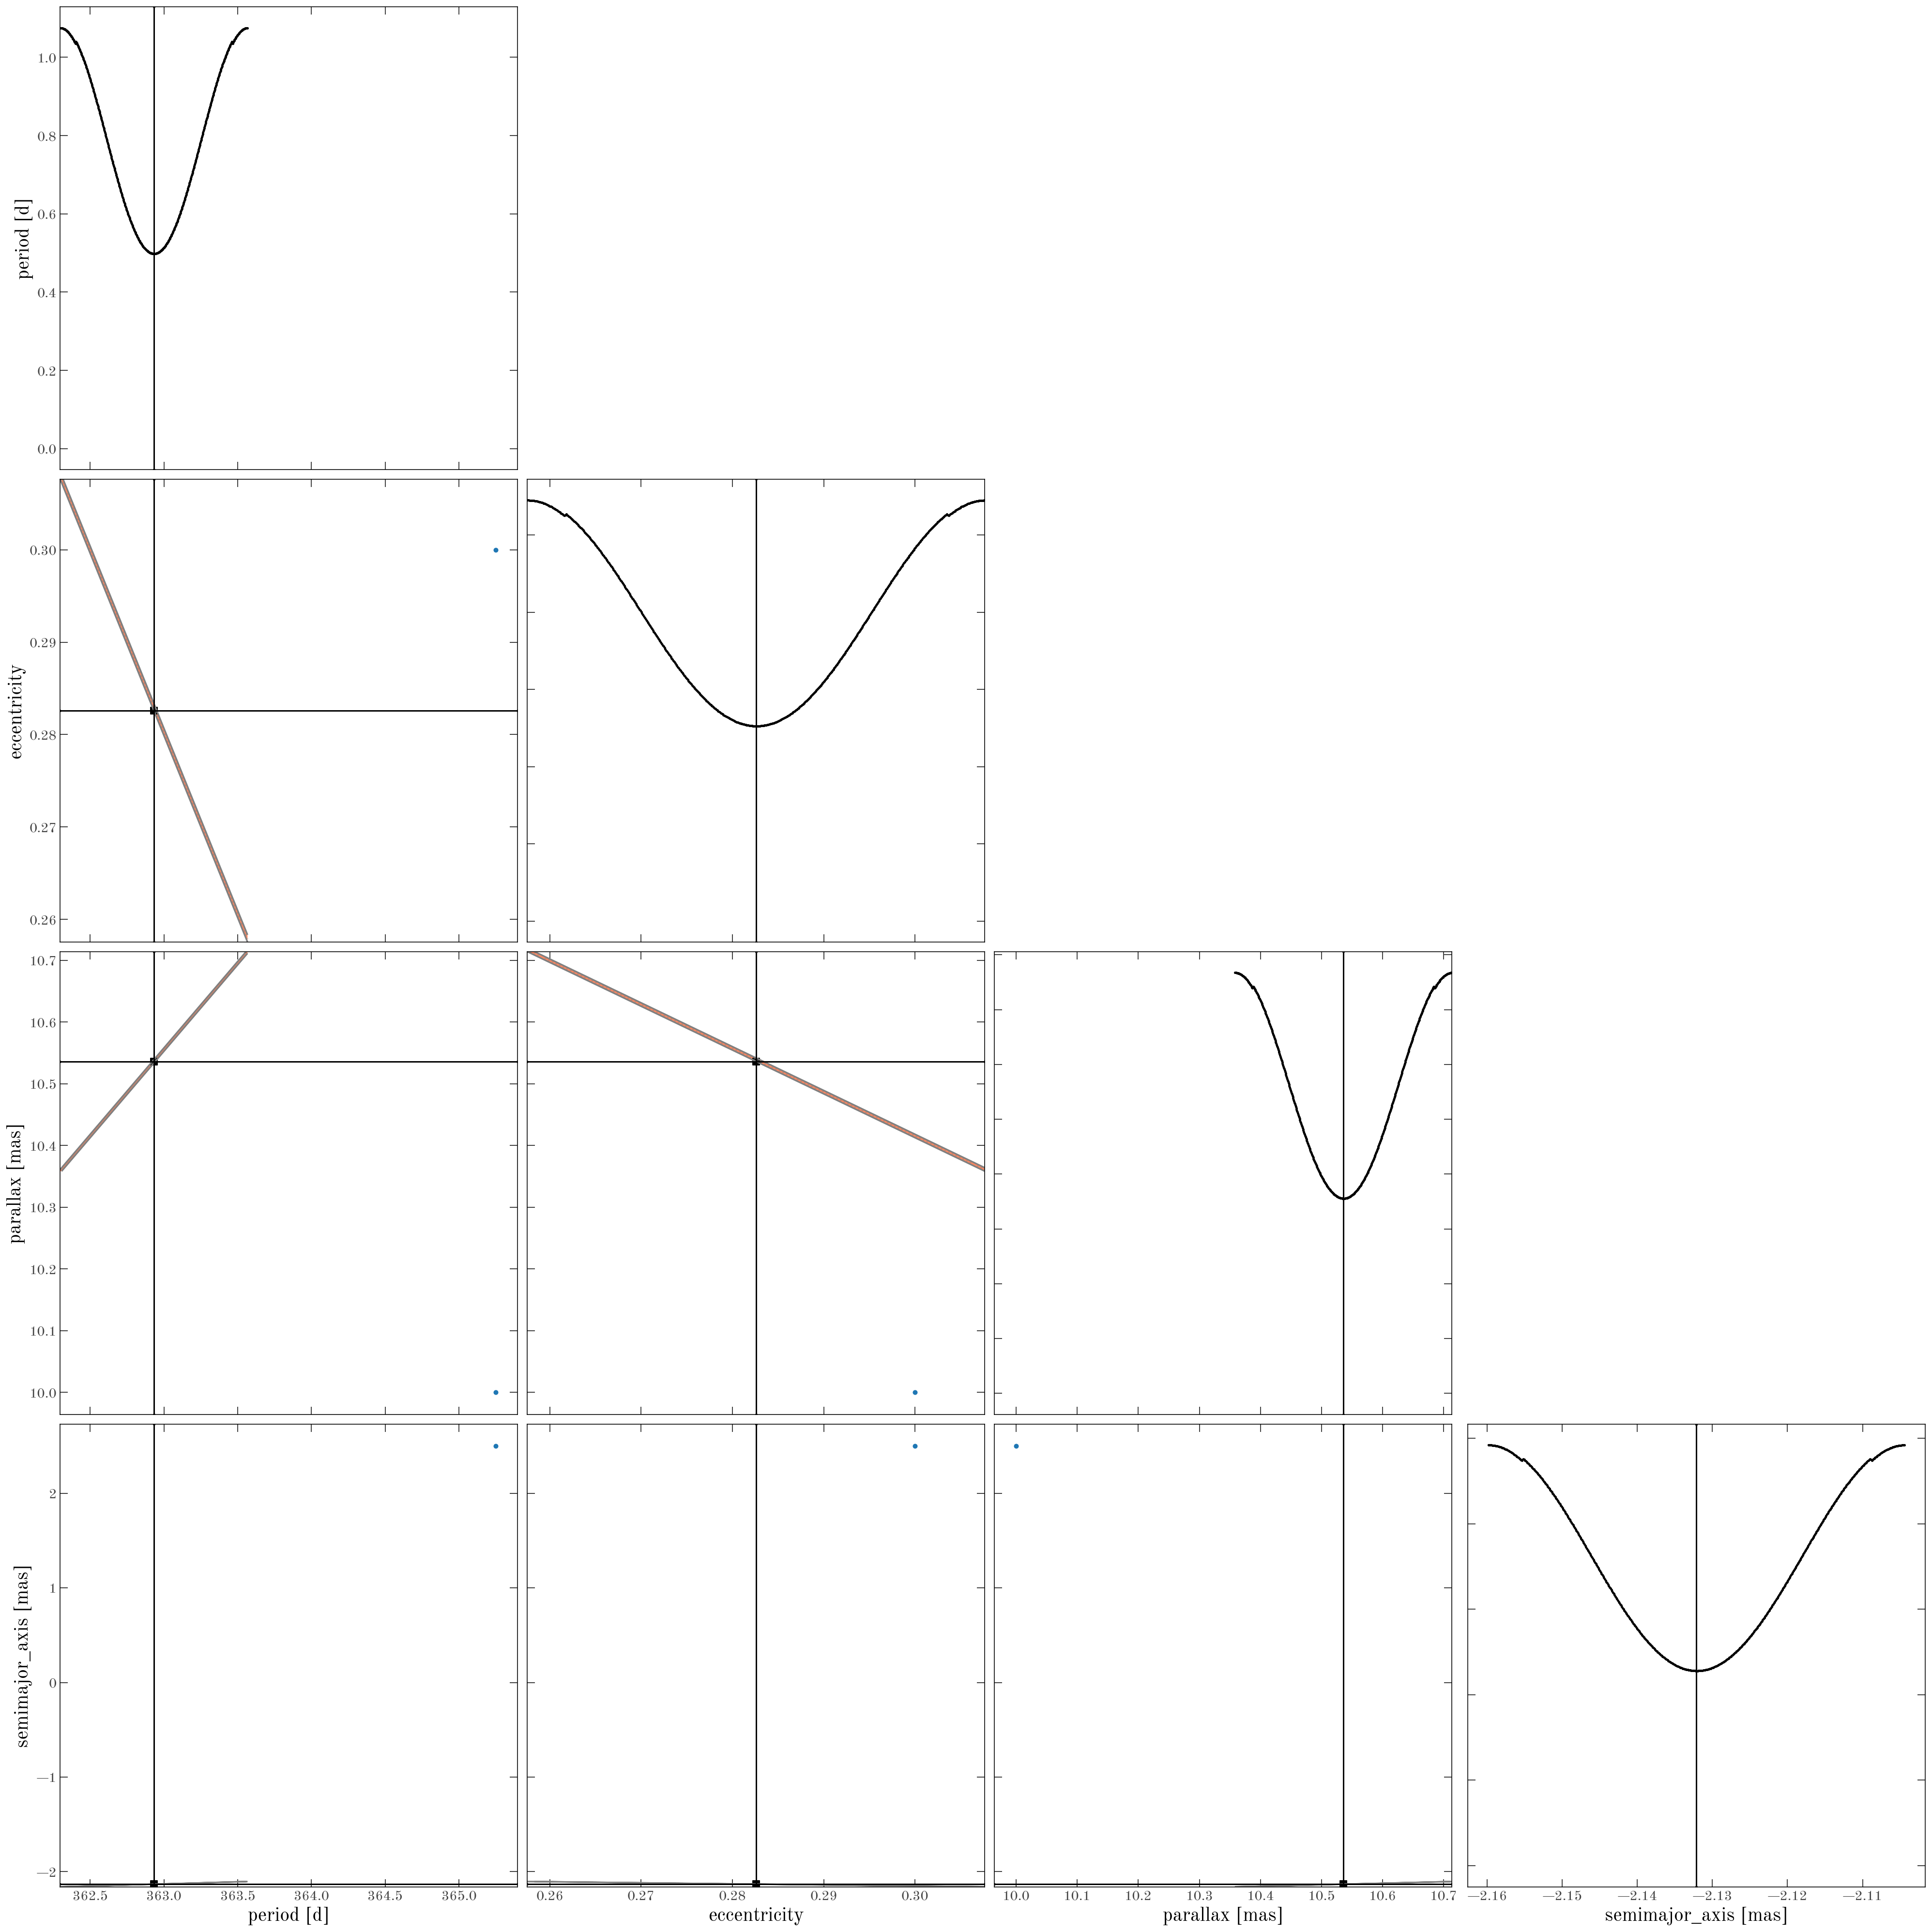

In [11]:
# Define true values for overplotting
truths = {
    "period": true_params["period"],
    "eccentricity": true_params["eccentricity"],
    "parallax": true_params["parallax"],
    "semimajor_axis": true_params["semimajor_axis"],
}

axes = samples.plot_corner(
    params=["period", "eccentricity", "parallax", "semimajor_axis"],
    truths=truths,
)

## Part 6: Saving and Loading Results

Samples can be saved to HDF5 format for later analysis.

In [12]:
# Save samples to HDF5
samples.to_hdf5("my_samples.h5")
print("Samples saved to my_samples.h5")

# Load samples back
from harv.samplers import Samples

loaded_samples = Samples.from_hdf5("my_samples.h5")
print(f"Loaded {loaded_samples.n_samples} samples")

Samples saved to my_samples.h5
Loaded 2 samples


/Users/aprice-whelan/projects/harv/src/harv/samplers/samples.py:418: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return cls(


In [13]:
# Clean up
import os

os.remove("my_samples.h5")

---

## Part 7: Working with Radial Velocity Data

harv also supports radial velocity (RV) observations. Let's simulate some RV data for the same system.

In [ ]:
# Simulate RV data
rv_data, rv_true_params = simulate_rv_sb1_data(
    seed=123,
    n_obs=7,
    # Orbital parameters (same as astrometry)
    period=Quantity(365.25, "day"),
    eccentricity=0.3,
    arg_peri=Quantity(45, "deg"),
    # RV-specific parameters
    K=Quantity(15, "km/s"),  # Semi-amplitude
    v0=Quantity(25, "km/s"),  # Systemic velocity
    rv_err=Quantity(0.5, "km/s"),  # Measurement error
)

print(f"Number of RV observations: {len(rv_data.time)}")
print(f"\nTrue RV parameters:")
for key, val in rv_true_params.items():
    print(f"  {key}: {val}")

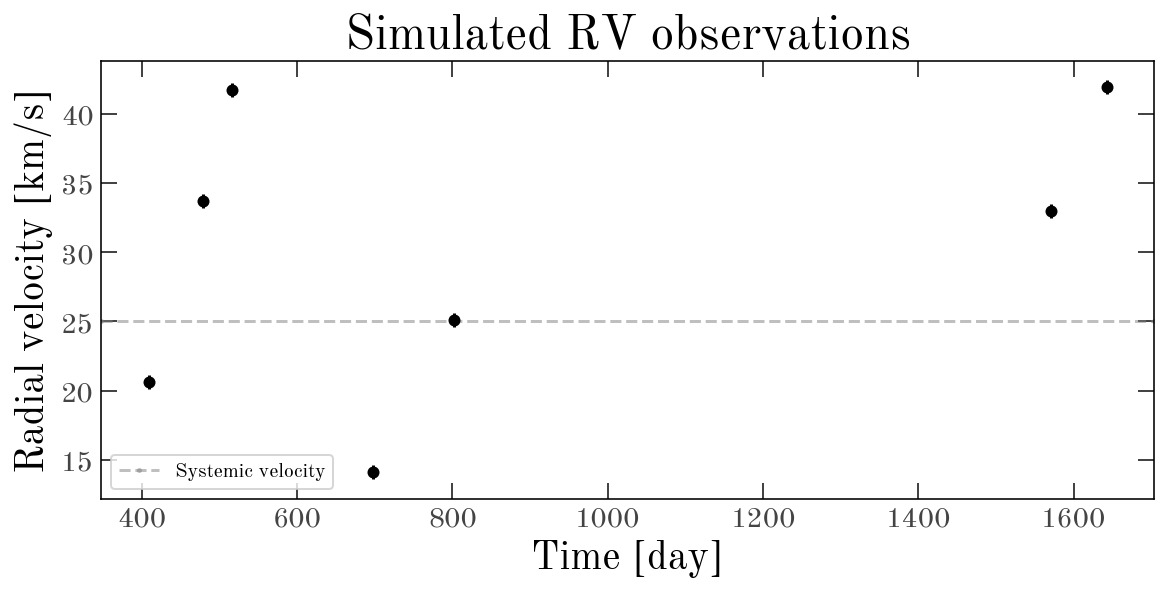

In [15]:
# Plot RV curve
fig, ax = plt.subplots(figsize=(8, 4))

times_day = rv_data.time.to_value("day")
ax.errorbar(
    times_day,
    rv_data.rv.to_value("km/s"),
    yerr=rv_data.rv_err.to_value("km/s"),
    fmt="o",
    ms=6,
    capsize=3,
)
ax.axhline(
    rv_true_params["v0"].to_value("km/s"),
    color="gray",
    ls="--",
    alpha=0.5,
    label="Systemic velocity",
)
ax.set_xlabel("Time [day]")
ax.set_ylabel("Radial velocity [km/s]")
ax.set_title("Simulated RV observations")
ax.legend()
plt.show()

In [16]:
# Create RV prior and run sampler
rv_prior = RejectionPrior.default_rv(
    log_period_min=1.0,
    log_period_max=4.0,
    linear_prior_scale=100.0,  # km/s scale for RV
)

print(f"RV prior has {rv_prior.n_nonlinear} nonlinear parameters")
print(f"  cos_i: {rv_prior.cos_i}")  # None for RV-only
print(f"  lon_asc_node: {rv_prior.lon_asc_node}")  # None for RV-only

RV prior has 4 nonlinear parameters
  cos_i: None
  lon_asc_node: None


Note that the RV-only prior has fewer parameters (4 instead of 6) because inclination and longitude of ascending node cannot be constrained from RV data alone.

In [17]:
# Run rejection sampling on RV data
rv_sampler = RejectionSampler(rv_prior)

rv_samples = rv_sampler.run(
    rv_data,
    n_prior_samples=5_000_000,
    seed=456,
)

print(f"Number of accepted RV samples: {rv_samples.n_samples}")
print(f"Acceptance rate: {rv_samples.n_samples / 500_000:.2%}")

Number of accepted RV samples: 5
Acceptance rate: 0.00%


/Users/aprice-whelan/projects/harv/src/harv/samplers/rejection.py:251: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Samples(


In [18]:
rv_samples["period"]

Quantity(Array([366.81173332, 364.96830762, 367.82641984, 366.31710189,
                367.00613529], dtype=float64), unit='d')

In [19]:
rv_samples["eccentricity"]

array([0.15702211, 0.19327767, 0.04551713, 0.19736087, 0.21899555])

In [20]:
# Summary statistics for RV samples
rv_summary = rv_samples.summary(["period", "eccentricity", "K", "v0"])

print("RV Parameter summary:")
print("-" * 60)
for param, stats in rv_summary.items():
    print(f"\n{param}:")
    for stat_name, value in stats.items():
        print(f"  {stat_name}: {value}")

RV Parameter summary:
------------------------------------------------------------

period:
  median: Quantity['time'](366.81173332, unit='d')
  mean: Quantity['time'](366.58593959, unit='d')
  std: Quantity['time'](0.94396455, unit='d')
  p16: Quantity['time'](365.83153595, unit='d')
  p84: Quantity['time'](367.30143773, unit='d')

eccentricity:
  median: 0.1932776723355982
  mean: 0.16243466643928262
  std: 0.061756408709535006
  p16: 0.11688031704469734
  p84: 0.20514935591024439

K:
  median: Quantity['speed'](-14.29344554, unit='km / s')
  mean: Quantity['speed'](-2.95096885, unit='km / s')
  std: Quantity['speed'](14.29831136, unit='km / s')
  p16: Quantity['speed'](-14.76390949, unit='km / s')
  p84: Quantity['speed'](14.49824197, unit='km / s')

v0:
  median: Quantity['speed'](26.31437155, unit='km / s')
  mean: Quantity['speed'](26.38386971, unit='km / s')
  std: Quantity['speed'](0.76017676, unit='km / s')
  p16: Quantity['speed'](25.89620877, unit='km / s')
  p84: Quantity['

In [21]:
# Compare RV results with true values
print("Comparison with true values (RV only):")
print("-" * 60)

# Period
rv_period_median = rv_samples.median("period")
print(f"Period: {rv_period_median} (true: {rv_true_params['period']})")

# Eccentricity
rv_ecc_median = rv_samples.median("eccentricity")
print(f"Eccentricity: {float(rv_ecc_median):.3f} (true: {rv_true_params['eccentricity']})")

# Semi-amplitude K
rv_K_median = rv_samples.median("K")
print(f"K: {rv_K_median} (true: {rv_true_params['K']})")

# Systemic velocity
rv_v0_median = rv_samples.median("v0")
print(f"v0: {rv_v0_median} (true: {rv_true_params['v0']})")

Comparison with true values (RV only):
------------------------------------------------------------
Period: Quantity['time'](366.81173332, unit='d') (true: Quantity['time'](365.25, unit='d'))
Eccentricity: 0.193 (true: 0.3)
K: Quantity['speed'](-14.29344554, unit='km / s') (true: Quantity['speed'](15, unit='km / s'))
v0: Quantity['speed'](26.31437155, unit='km / s') (true: Quantity['speed'](25, unit='km / s'))


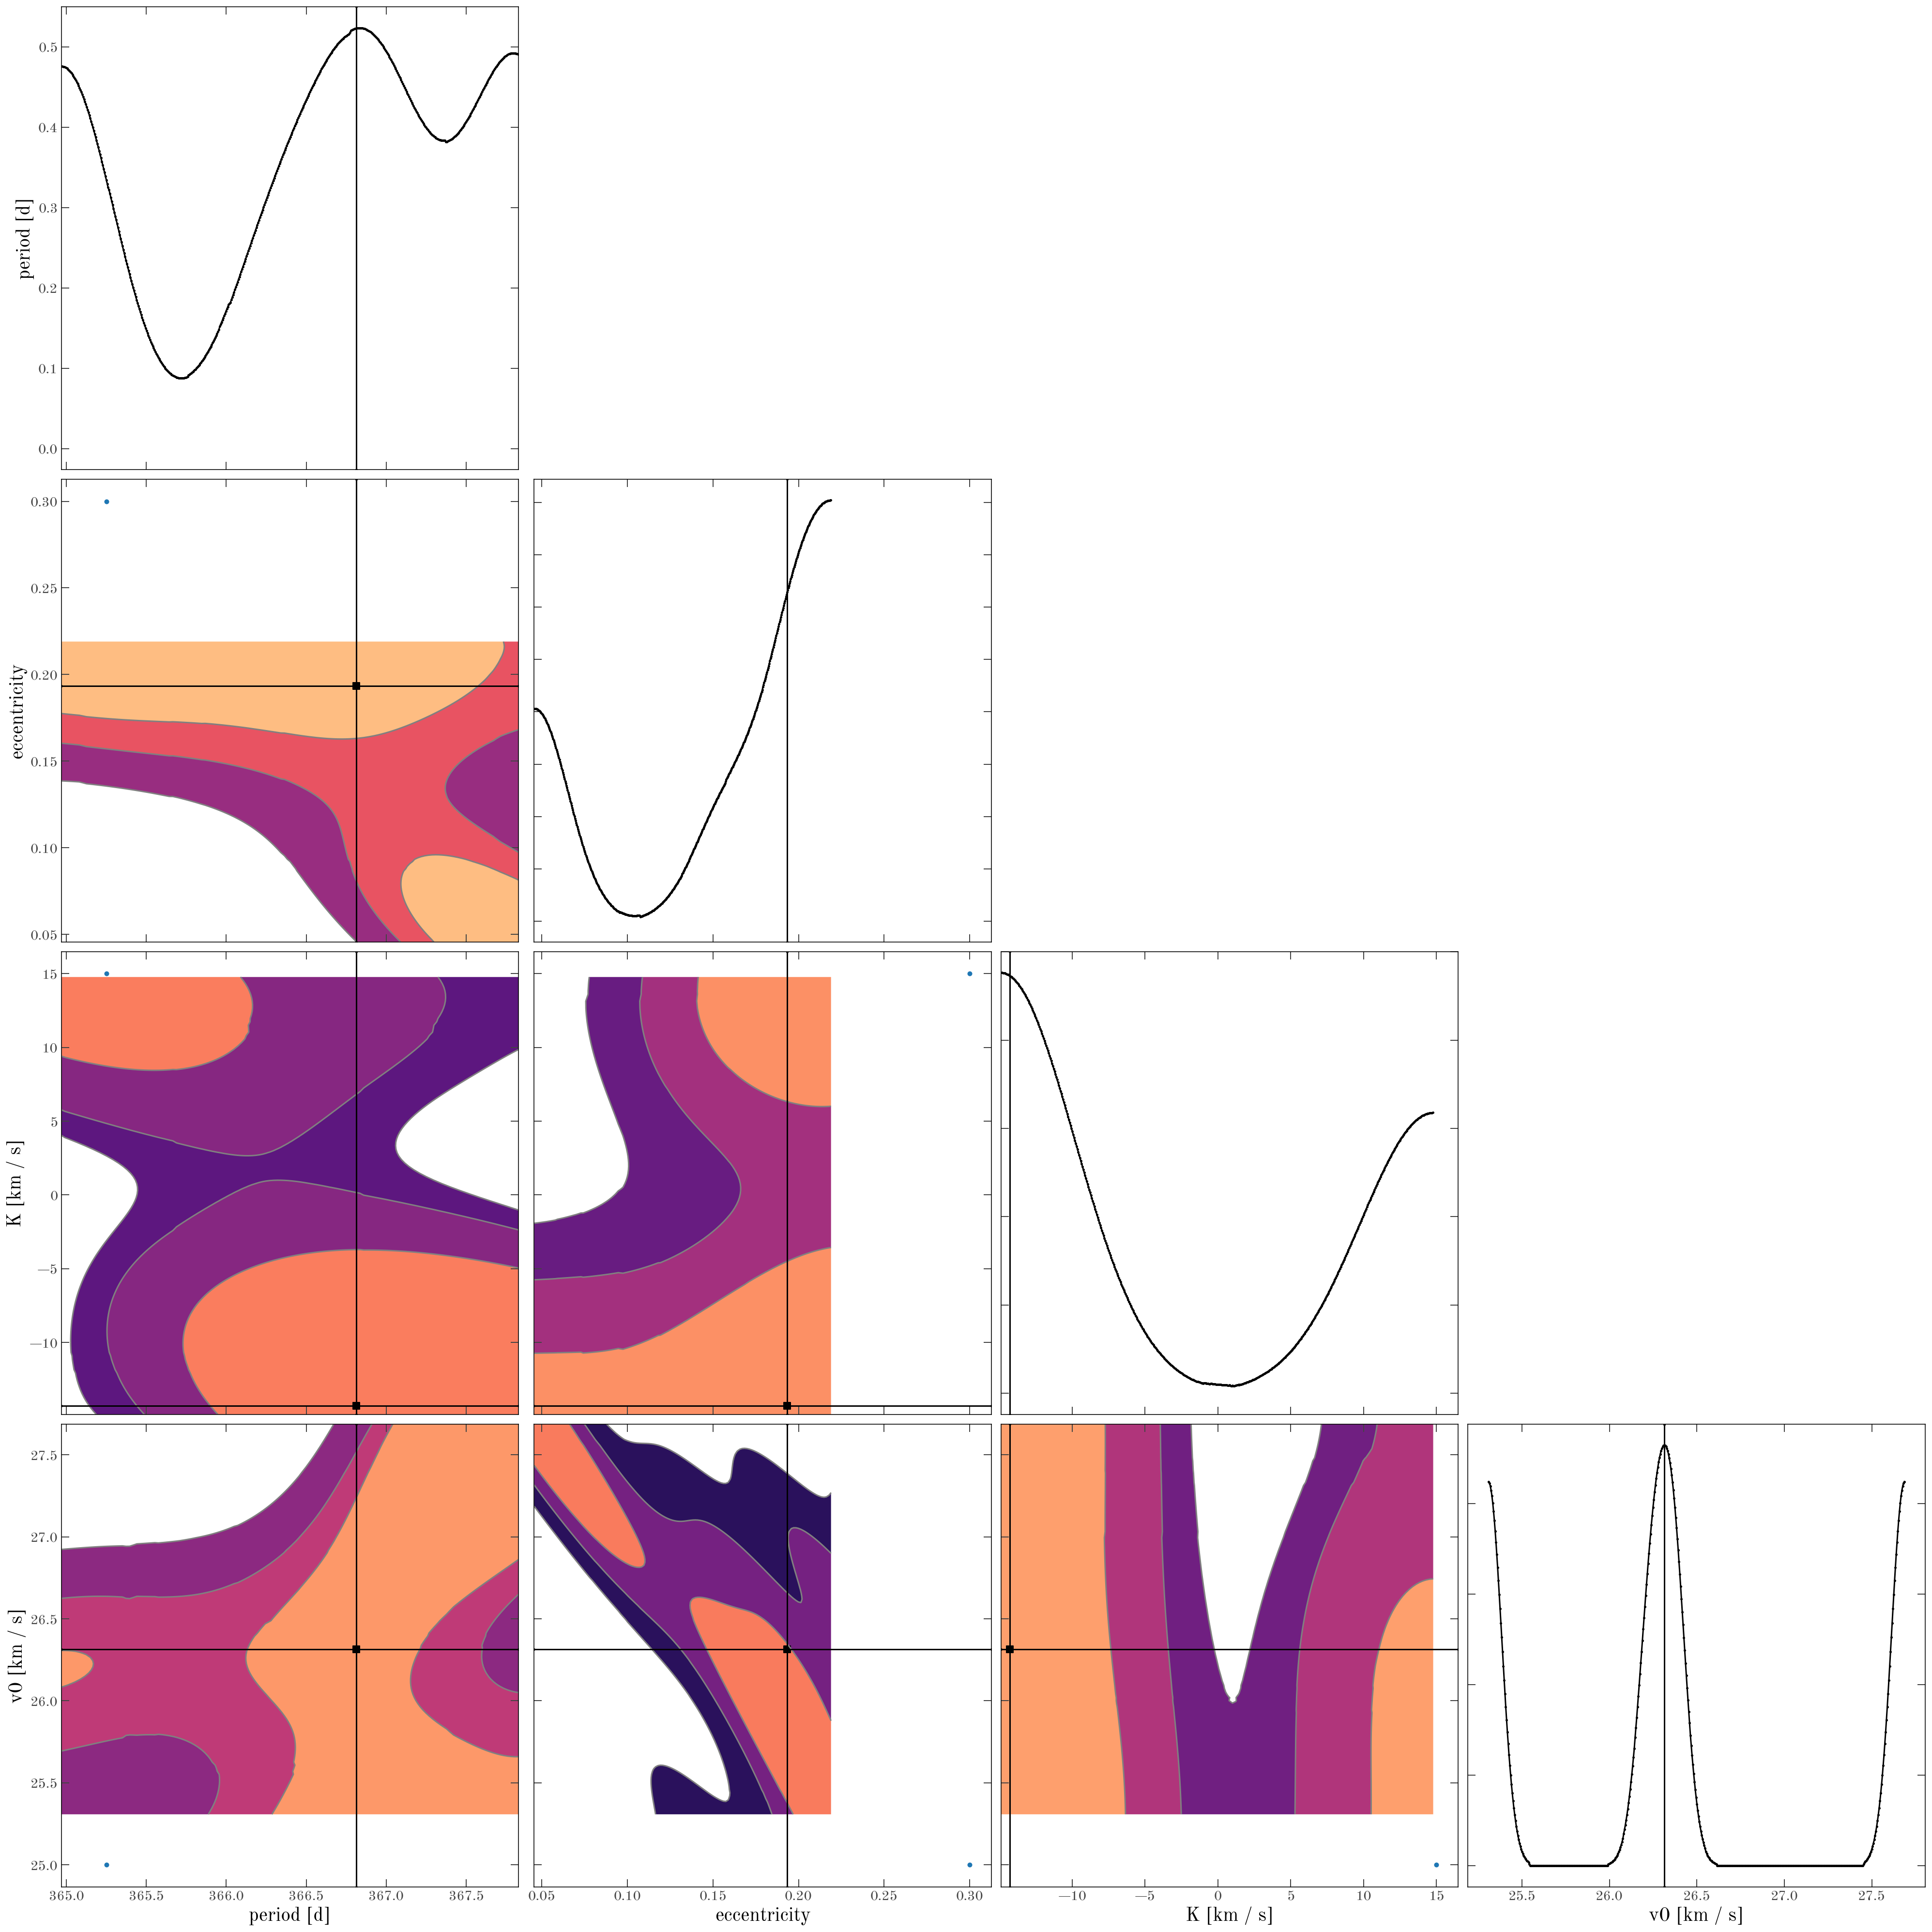

In [22]:
# Corner plot for RV samples
rv_truths = {
    "period": rv_true_params["period"],
    "eccentricity": rv_true_params["eccentricity"],
    "K": rv_true_params["K"],
    "v0": rv_true_params["v0"],
}

rv_axes = rv_samples.plot_corner(
    params=["period", "eccentricity", "K", "v0"],
    truths=rv_truths,
)

---

## Part 8: Combined Astrometry + RV Analysis

The real power of harv comes from combining multiple data types. When you have both astrometry and RV data, you can break degeneracies and get much better constraints.

Use `SourceData` to combine multiple datasets:

In [23]:
# Combine astrometry and RV data
combined_data = SourceData(
    gaia=astro_data,
    rv=rv_data,
)

print(f"Combined data contains:")
for name in combined_data.keys():
    dataset = combined_data[name]
    print(f"  {name}: {type(dataset).__name__} with {len(dataset.time)} observations")

Combined data contains:
  gaia: GaiaAstrometryData with 50 observations
  rv: RadialVelocityData with 7 observations


In [24]:
# Create combined prior
combined_prior = RejectionPrior.default_combined(
    log_period_min=1.0,
    log_period_max=4.0,
)

print(f"Combined prior has {combined_prior.n_nonlinear} nonlinear parameters")

Combined prior has 6 nonlinear parameters


---

## Part 9: Custom Priors

You can create custom priors by specifying individual distributions:

In [25]:
import jax.numpy as jnp
import numpyro.distributions as dist

# Create a custom prior with different distributions
custom_prior = RejectionPrior(
    # Narrower period range
    log_period=dist.Uniform(2.0, 3.0),  # 100-1000 days
    # Flat eccentricity prior instead of Kipping
    eccentricity=dist.Uniform(0.0, 0.8),
    # Standard phase prior
    phase_peri=dist.Uniform(0.0, 1.0),
    # Orientation priors (for astrometry)
    cos_i=dist.Uniform(-1.0, 1.0),
    arg_peri=dist.Uniform(0.0, 2.0 * jnp.pi),
    lon_asc_node=dist.Uniform(0.0, 2.0 * jnp.pi),
    # Linear parameter scale
    linear_prior_scale=500.0,
)

print(f"Custom prior created with {custom_prior.n_nonlinear} nonlinear parameters")

Custom prior created with 6 nonlinear parameters


### Multi-instrument RV with offsets

When you have RV data from multiple instruments, you can model instrument-specific velocity offsets:

In [26]:
# Create prior with multi-instrument offsets
multi_inst_prior = RejectionPrior.default_rv(
    offsets={
        "HARPS": None,  # Reference instrument (no offset)
        "ESPRESSO": dist.Normal(0, 5.0),  # Offset prior: N(0, 5) km/s
        "HIRES": dist.Normal(0, 10.0),  # Offset prior: N(0, 10) km/s
    }
)

print(f"Multi-instrument prior offsets: {multi_inst_prior.offsets}")

Multi-instrument prior offsets: {'HARPS': None, 'ESPRESSO': <numpyro.distributions.continuous.Normal object at 0x3771d2cc0 with batch shape () and event shape ()>, 'HIRES': <numpyro.distributions.continuous.Normal object at 0x36b176930 with batch shape () and event shape ()>}


---

## Summary

In this tutorial, you learned how to:

1. **Simulate data** using `simulate_gaia_epoch_astrometry()` and `simulate_rv_sb1_data()`

2. **Set up priors** using factory methods like `RejectionPrior.default_astrometry()`, `default_rv()`, and `default_combined()`

3. **Run rejection sampling** with `RejectionSampler.run()`

4. **Analyze results** using `Samples` methods like `median()`, `summary()`, and `plot_corner()`

5. **Save and load results** with `to_hdf5()` and `from_hdf5()`

6. **Combine data types** using `SourceData`

7. **Create custom priors** with arbitrary numpyro distributions

### Next Steps

- Explore the [API reference](../api/) for detailed documentation
- Check out advanced tutorials on:
  - Iterative rejection sampling for challenging posteriors
  - Initializing MCMC from rejection samples
  - Working with real Gaia data